# Time Series Forecasting

In [34]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

### 

>Creamos una funcion que usaremos más adelante

In [35]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

## Carga de datos

In [36]:
with open('/workspaces/adamcn10-intro-ml/data/processed/time-series-Xy-train.pkl', 'rb') as file:
    Xy_train = pickle.load(file)

with open('/workspaces/adamcn10-intro-ml/data/processed/time-series-Xy-test.pkl', 'rb') as file:
    Xy_test = pickle.load(file)

df = pd.concat([Xy_train, Xy_test])
df

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633
...,...
2023-08-30 17:10:08.079328,989.600354
2023-08-31 17:10:08.079328,994.987326
2023-09-01 17:10:08.079328,995.814415


## Análisis y graficos

### Análisis visual

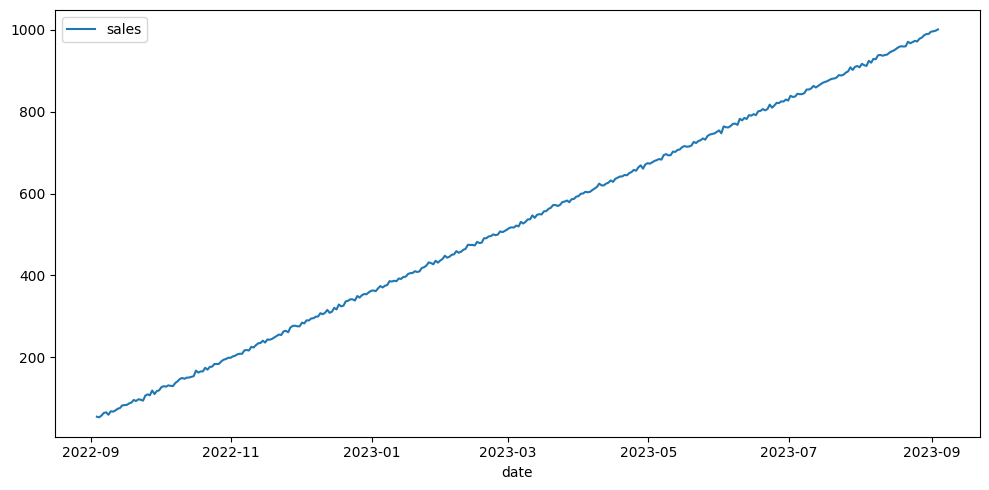

In [37]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)

plt.tight_layout()
plt.show()

>Podemos ver a priori que parece que la serie temporal tiene una tendencia positiva lineal, no vemos ninguna estacionalidad clara y en cuanto a variabilidad, puntos atípicvos y puntos de inflexión no podemos ver demasiada cosa clara.

### Análisis de tendencia

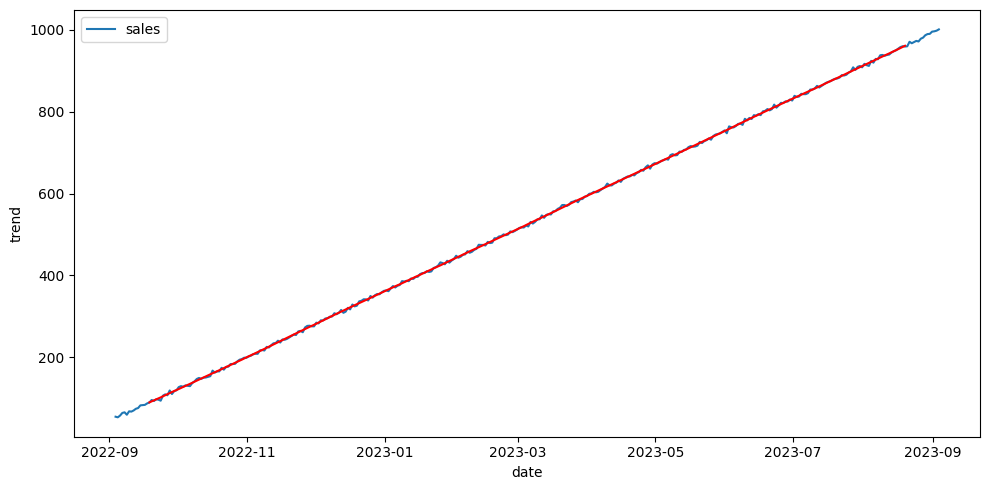

In [38]:
decomposition = seasonal_decompose(df, period = 30)
trend = decomposition.trend
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = trend, c='r')

plt.tight_layout()
plt.show()

>Vemos en rojo claramente una tendencia lineal positiva constante y a lo largo de todo el tiempo estudiado

### Análisis de estacionalidad

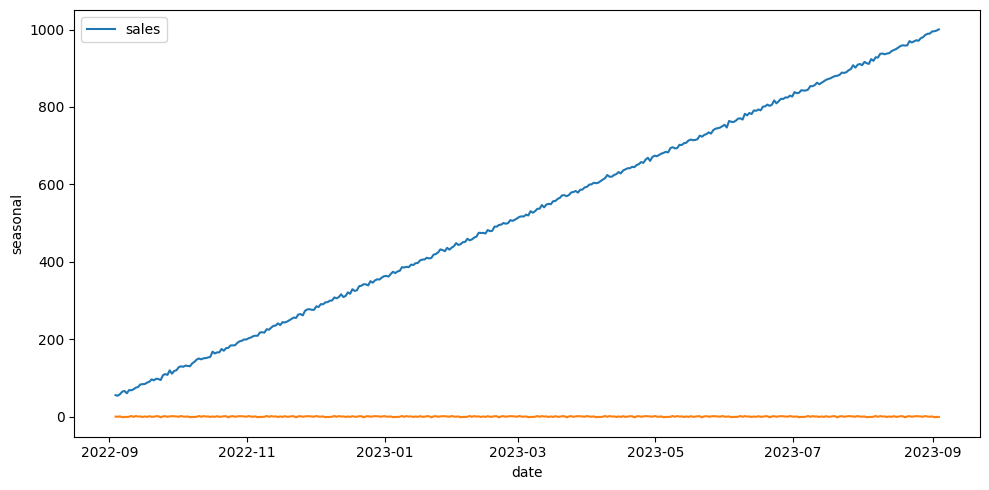

In [39]:
seasonal = decomposition.seasonal
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = seasonal)

plt.tight_layout()
plt.show()

>Al ver la función aplanada cuesta ver estacionalidad, ya que no se aprecian a simple vista las variaciones en esta, parece bastante constante

### Prueba Dickey-Fuller

>Haremos la prueba Dickey-Fuller para comprobar la hipotesis nula de que la serie temporal NO es estacionaria y en el caso de que su p-value sea menor de 0.05 podremos negar la hipotesis nula y afirmar en consecuencia que la serie temporal SI es estacionaria

In [40]:
test_stationarity(df)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

>Podemos ver un p-value mucho mayor al 0.05 que considaramos habitualmente para negar la hipotesis nula, por ello no podemos negar la hipotesis nula de que esta serie temporal no es estacionaría y por ello no la podremos tratar como estacionaria

### Análisis de variabilidad

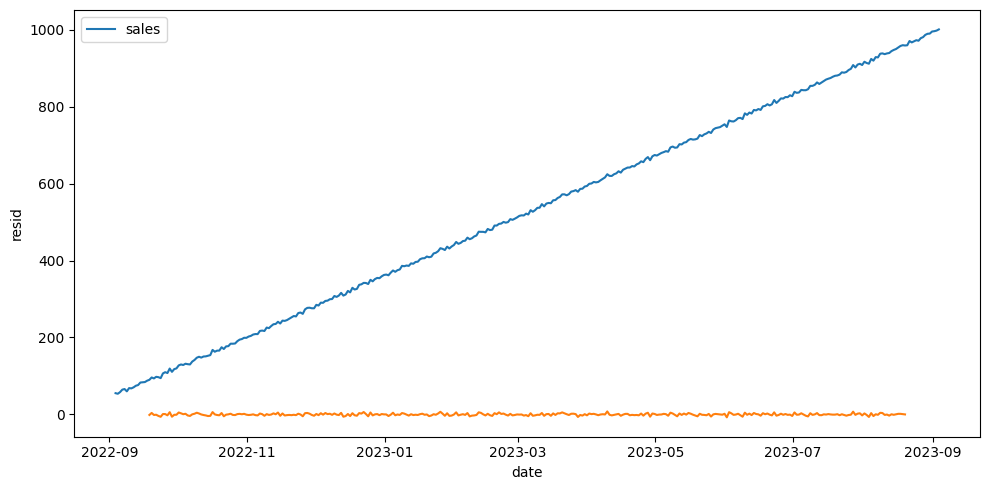

In [41]:
residual = decomposition.resid
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = residual)

plt.tight_layout()
plt.show()

>Al estudiar la tendencia y haber visto que era lineal podiamos llegar anteriormente a la misma conclusión a la que podemos llegar con este análisis y esta es que la variabilidad es bastante constante, de un valor a su posterior hay un aumento muy similar en la mayoría de los elementos de la seria temporal

### Análisis de autocorrelación

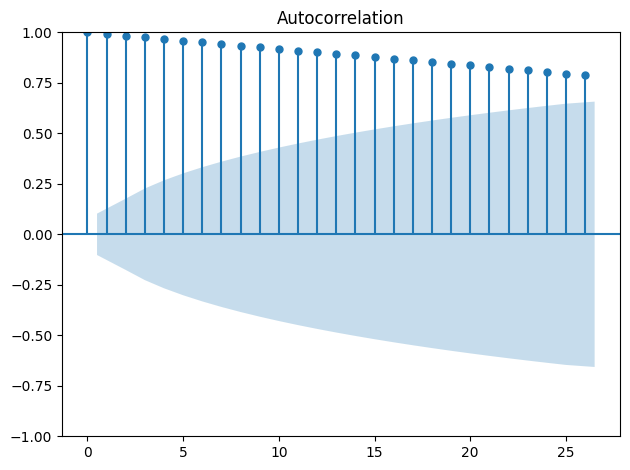

In [42]:
plot_acf(df)
plt.tight_layout()
plt.show()

>Vemos una autocorrelación bastante alta, lo que significa que los valores pueden depender mayoritariamente de los anteriores a estos, pero vemos que cada vez hay una autocorrelación menor y esto puede acabar dificultando una buena predicción de valores futuros.

### Análisis de las diferencias

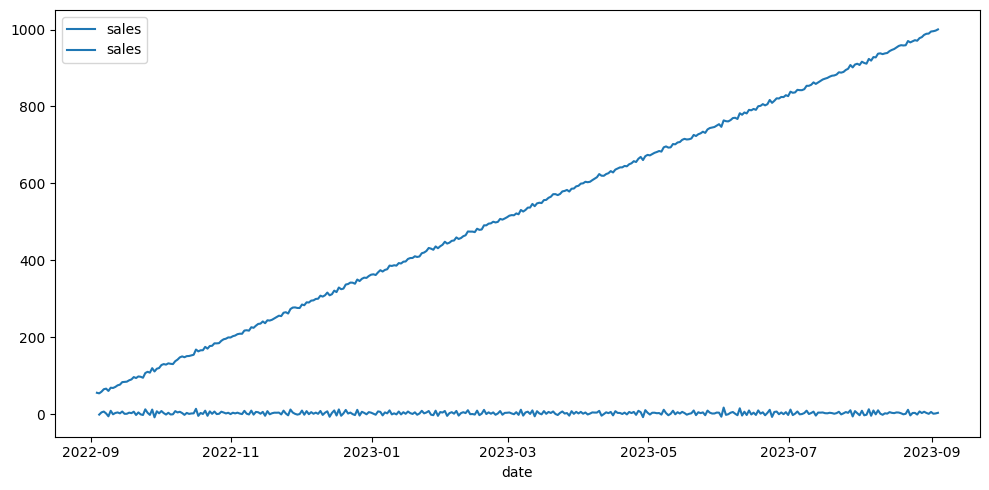

In [43]:
df_diff = df.diff().dropna()
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = df_diff)

plt.tight_layout()
plt.show()

>Vemos como se muestra la gráfica de la función que muestra las diferencias de los elementos de la linea temporal y sus elementos anteriores y analizaremos también si esta si que es estacionaria.

In [44]:
test_stationarity(df_diff)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

>En este caso el p-value que si que es claramente menor al 0.05 que marcamabos como límite, así que en este caso podemos negar claramente la hipotesis nula que dice que no es estacionaria y por ello podemos afirmar que la función de las diferencias de la serie temporal si que es estacionaría y por tanto podemos aplicar ARIMA sobre esta.

## Modelado y Predicción

>Cómo la serie temporal no es estacionaria pero sus diferencias sí, convertiremos Xy_train y Xy_test en sus versiones de sus diferencias.

In [45]:
Xy_train_diff = Xy_train.diff().dropna()
Xy_test_diff = Xy_test.diff().dropna()

In [46]:
model = auto_arima(Xy_train_diff, seasonal = True, trace = True, m = 30)
model.summary()

Performing stepwise search to minimize aic


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.

 ARIMA(2,0,2)(1,0,1)[30] intercept   : AIC=1489.163, Time=4.62 sec
 ARIMA(0,0,0)(0,0,0)[30] intercept   : AIC=1683.985, Time=0.01 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,0,0)[30] intercept   : AIC=1589.321, Time=0.53 sec


...

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,3)(0,0,1)[30] intercept   : AIC=inf, Time=2.52 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,2)(0,0,1)[30]             : AIC=1733.101, Time=0.44 sec

Best model:  ARIMA(0,0,2)(0,0,1)[30] intercept
Total fit time: 59.846 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  292
Model:             SARIMAX(0, 0, 2)x(0, 0, [1], 30)   Log Likelihood                -736.739
Date:                              Mon, 21 Jul 2025   AIC                           1483.479
Time:                                      08:40:43   BIC                           1501.863
Sample:                                  09-04-2022   HQIC                          1490.843
                                       - 06-22-2023                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.5997      0.012    223.011      0.000       2.577       2.623
ma.L1         -1.0278      0.055    -18.834      0.000      -1.135      -0.921
ma.L2          0.0973      0.055      1.760      0.078      -0.011       0.206
ma.S.L30      -0.1091      0.069     -1.572      0.116      -0.245       0.027
sigma2         9.0225      0.808     11.161      0.000       7.438      10.607
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.08
Prob(Q):                              0.97   Prob(JB):                         0.58
Heteroskedasticity (H):               1.00   Skew:                             0.06
Prob(H) (two-sided):                  0.99   Kurtosis:                         2.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

>Entrenamos el modeo ARIMA con el train splitteado para después probar a predecir el test de 73 elementos como los que quitamos en el Split de eda

In [47]:
forecast = model.predict(73)
forecast

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


2023-06-23 17:10:08.079328   -4.269585
2023-06-24 17:10:08.079328    3.881686
2023-06-25 17:10:08.079328    1.842747
2023-06-26 17:10:08.079328    2.458713
2023-06-27 17:10:08.079328    2.871825
                                ...   
2023-08-30 17:10:08.079328    2.599727
2023-08-31 17:10:08.079328    2.599727
2023-09-01 17:10:08.079328    2.599727
2023-09-02 17:10:08.079328    2.599727
2023-09-03 17:10:08.079328    2.599727
Freq: D, Length: 73, dtype: float64

In [48]:
Xy_train_diff

,sales
date,
2022-09-04 17:10:08.079328,-1.488946
2022-09-05 17:10:08.079328,4.338482
2022-09-06 17:10:08.079328,6.389205
2022-09-07 17:10:08.079328,1.482734
2022-09-08 17:10:08.079328,-5.931768
...,...
2023-06-18 17:10:08.079328,1.038758
2023-06-19 17:10:08.079328,4.438824
2023-06-20 17:10:08.079328,-3.187062


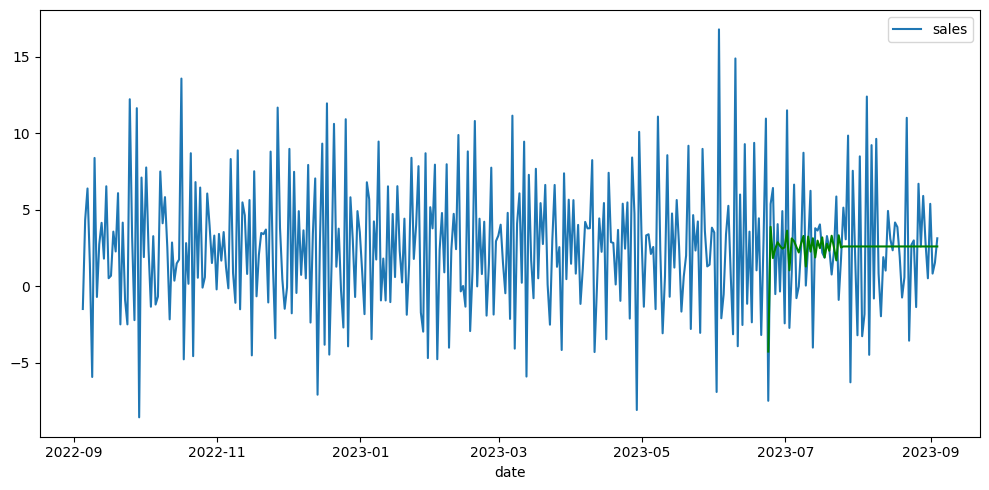

In [49]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df_diff)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()
plt.show()

>Aquí vemos la predicción de las diferencias en verde sobre como ha sido en la realidad por detrás en azúl, no se ve claramente la calidad de la predicción de esta manera por lo que mostraremos también el grafico con la serie temporal y no con solo las diferencias.

In [50]:
pred = forecast.cumsum() + Xy_train['sales'].iloc[-1]
pred

2023-06-23 17:10:08.079328     812.642165
2023-06-24 17:10:08.079328     816.523851
2023-06-25 17:10:08.079328     818.366597
2023-06-26 17:10:08.079328     820.825310
2023-06-27 17:10:08.079328     823.697135
                                 ...     
2023-08-30 17:10:08.079328     989.951175
2023-08-31 17:10:08.079328     992.550902
2023-09-01 17:10:08.079328     995.150629
2023-09-02 17:10:08.079328     997.750355
2023-09-03 17:10:08.079328    1000.350082
Freq: D, Length: 73, dtype: float64

>Aquí estamos generando la predicción general, no la de diferencias y ahora la mostraremos gráficamente.

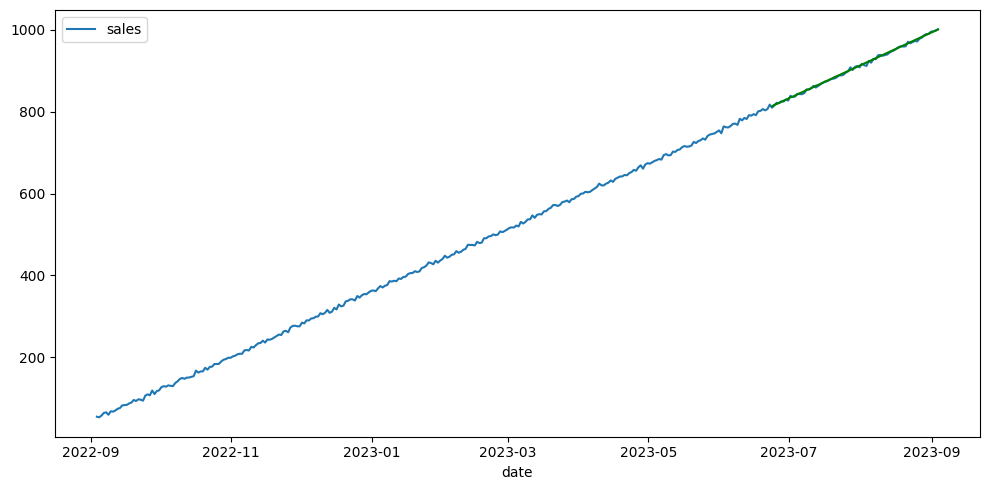

In [51]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = pred, c = "green")

plt.tight_layout()
plt.show()

>Podemos ver que pese a parecer fallar en las fluctuaciones, de media la precicción parece adecuada y que se parece bastante a como sucedieron las ventas al final

In [52]:
sum_ventas = {
    'Suma de las ventas reales tras el train:' : Xy_test.sum(), 
    'Suma de las ventas predichas:' : pred.sum(),
    'Diferencia en estas sumas:' : (Xy_test.sum() - pred.sum()),
    'Diferencia relativa de las sumas:' : (Xy_test.sum() - pred.sum())/Xy_test.sum()
}
sum_ventas

{'Suma de las ventas reales tras el train:': sales    66123.812283
 dtype: float64,
 'Suma de las ventas predichas:': 66194.20823444832,
 'Diferencia en estas sumas:': sales   -70.395951
 dtype: float64,
 'Diferencia relativa de las sumas:': sales   -0.001065
 dtype: float64}

>Vemos también que si sumamos las ventas que ocurren tras las separadas para entrenar al modelo, el resultado es muy similar a la suma de las ventas predecidas, si calculamos la diferencia entre estas vemos un valor absoluto de 70 y uno relativo de aproximadamente un 0.1%, con esta información se podría decir que el modelo es bastante bueno y su predicción bastante precisa en lo general aunque no prediga bien sus fluctuaciones.

## Guardado de Modelos

In [53]:
with open('/workspaces/adamcn10-intro-ml/models/time-series-forecasting.pkl', 'wb') as file:
    pickle.dump(model, file)